## Business Case context – Customer Behavior & Segmentation

The sections below provide monthly revenue trends, top categories, and customer segmentation/tenure; additional RFM and geographic breakdowns can be layered on these same BigQuery tables if needed.

In [2]:
import os
import sys

import pandas as pd
import pandas_gbq
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from config import BQ_PROJECT, BQ_DATASET_DW

def bq_table(name):
    return f"`{BQ_PROJECT}.{BQ_DATASET_DW}.{name}`"

plt.style.use('ggplot')
sns.set_palette('husl')

/home/teoyongsong/miniconda3/envs/olist-bq/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 0. Order-level benchmarks (fact_orders)

The `fact_orders` table is built with **aggregate first → then join**: one row per order, so order-level metrics are correct (no join multiplication). Use it for benchmarks and order-level analytics.

In [3]:
query_benchmark = f"""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(gross_order_value), 0) AS total_merchandise_value,
    ROUND(SUM(payment_value), 0) AS total_payments_received,
    ROUND(AVG(total_items), 2) AS avg_items_per_order
FROM {bq_table('fact_orders')}
WHERE order_status = 'delivered'
"""
df_benchmark = pandas_gbq.read_gbq(query_benchmark, project_id=BQ_PROJECT)
df_benchmark

Downloading: 100%|██████████|


,total_orders,total_merchandise_value,total_payments_received,avg_items_per_order
0,96478,15419774.000000000,15422462.000000000,1.14


## 0b. Monthly revenue from fact_orders (order-level)

Using **fact_orders** (one row per order) for **delivered** orders only: monthly revenue, order count, and average order value.

**⚠️ Not apples-to-apples with Section 1:** Section 1 uses `fact_order_items` with **no** order_status filter (all orders, all statuses). Section 0b here uses **delivered only**. For an apples-to-apples comparison with Section 1, see **0b2** below (all orders from fact_orders).

In [4]:
query_monthly_fo = f"""
SELECT
    DATE_TRUNC(order_date_key, MONTH) AS month,
    SUM(gross_order_value) AS revenue,
    COUNT(*) AS orders,
    ROUND(AVG(gross_order_value), 2) AS avg_order_value
FROM {bq_table('fact_orders')}
WHERE order_status = 'delivered'
GROUP BY 1
ORDER BY 1
"""
df_monthly_fo = pandas_gbq.read_gbq(query_monthly_fo, project_id=BQ_PROJECT)
df_monthly_fo["month"] = pd.to_datetime(df_monthly_fo["month"])
df_monthly_fo.head(12)

Downloading: 100%|██████████|


,month,revenue,orders,avg_order_value
0,2016-09-01,143.460000000,1,143.460000000
1,2016-10-01,46490.660000000,265,175.440000000
2,2016-12-01,19.620000000,1,19.620000000
3,2017-01-01,127482.370000000,750,169.980000000
4,2017-02-01,271239.320000000,1653,164.090000000
5,2017-03-01,414330.950000000,2546,162.740000000
6,2017-04-01,390812.400000000,2303,169.700000000
7,2017-05-01,566851.400000000,3546,159.860000000
8,2017-06-01,490050.370000000,3135,156.320000000
9,2017-07-01,566299.080000000,3872,146.250000000


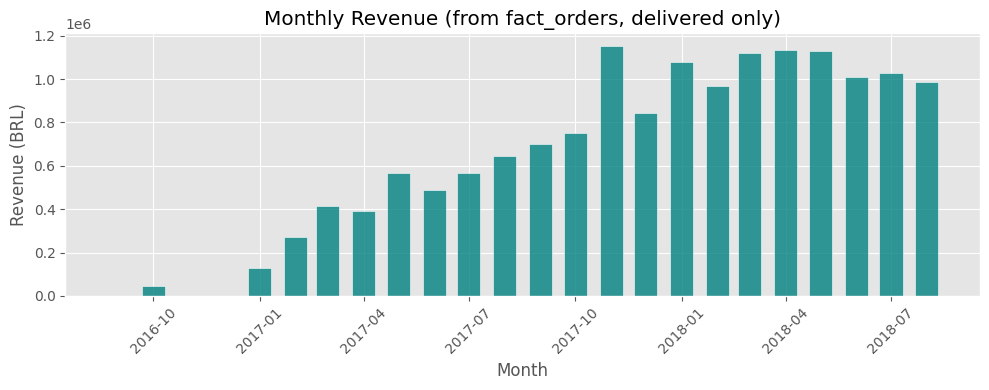

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_monthly_fo["month"], df_monthly_fo["revenue"], width=20, color='teal', edgecolor='white', alpha=0.8)
ax.set_title("Monthly Revenue (from fact_orders, delivered only)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 0b2. Apples-to-apples: monthly from fact_orders (all orders)

Same population as **Section 1**: **all orders** (no status filter). Total revenue and order count from `fact_orders` should match Section 1 (which uses `fact_order_items`), since both sum the same merchandise value across all orders.

In [6]:
# fact_orders: monthly, ALL orders (no filter) — apples-to-apples with Section 1
query_monthly_fo_all = f"""
SELECT
    DATE_TRUNC(order_date_key, MONTH) AS month,
    SUM(gross_order_value) AS revenue_fo,
    COUNT(*) AS orders_fo
FROM {bq_table('fact_orders')}
GROUP BY 1
ORDER BY 1
"""
df_monthly_fo_all = pandas_gbq.read_gbq(query_monthly_fo_all, project_id=BQ_PROJECT)
df_monthly_fo_all["month"] = pd.to_datetime(df_monthly_fo_all["month"])

# Compare totals: fact_orders (all) vs fact_order_items (section 1)
totals_fo = df_monthly_fo_all.agg({"revenue_fo": "sum", "orders_fo": "sum"})
totals_fi = df_monthly.agg({"revenue": "sum", "orders": "sum"})
print("Apples-to-apples (all orders):")
print(f"  fact_orders:   revenue={totals_fo['revenue_fo']:,.0f}  orders={totals_fo['orders_fo']:,.0f}")
print(f"  fact_order_items (Section 1): revenue={totals_fi['revenue']:,.0f}  orders={totals_fi['orders']:,.0f}")
df_monthly_fo_all.head(12)

Downloading: 100%|██████████|


NameError: name 'df_monthly' is not defined

## 0c. Orders by status (fact_orders)

Order counts and total revenue by **order_status** from fact_orders. All orders (not only delivered).

In [7]:
query_status = f"""
SELECT
    order_status,
    COUNT(*) AS order_count,
    ROUND(SUM(gross_order_value), 0) AS total_revenue
FROM {bq_table('fact_orders')}
GROUP BY order_status
ORDER BY order_count DESC
"""
df_status = pandas_gbq.read_gbq(query_status, project_id=BQ_PROJECT)
df_status

Downloading: 100%|██████████|


,order_status,order_count,total_revenue
0,delivered,96478,15419774.000000000
1,shipped,1107,177129.000000000
2,canceled,625,105886.000000000
3,unavailable,609,2140.000000000
4,invoiced,314,68989.000000000
5,processing,301,69394.000000000
6,created,5,None
7,approved,2,241.000000000


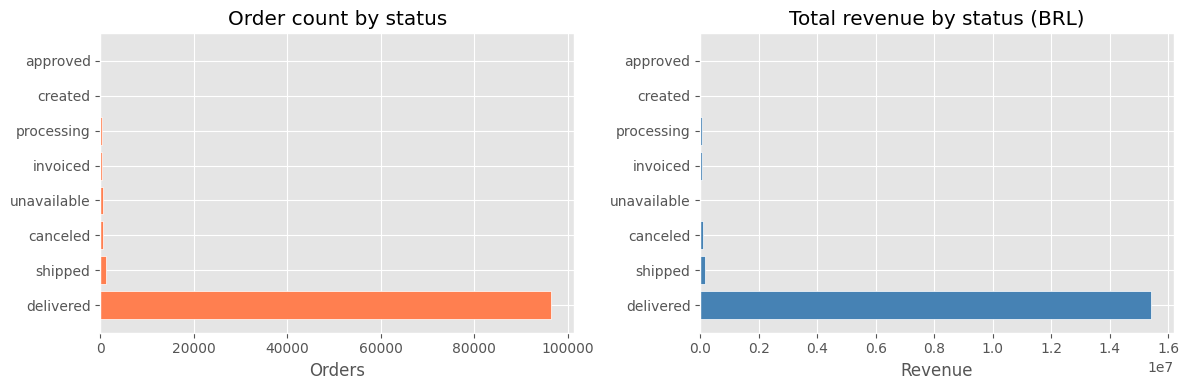

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(df_status["order_status"], df_status["order_count"], color='coral', edgecolor='white')
axes[0].set_title("Order count by status")
axes[0].set_xlabel("Orders")
axes[1].barh(df_status["order_status"], df_status["total_revenue"], color='steelblue', edgecolor='white')
axes[1].set_title("Total revenue by status (BRL)")
axes[1].set_xlabel("Revenue")
plt.tight_layout()
plt.show()

## 0d. Average order value & payment alignment (fact_orders)

Summary stats from **fact_orders** (delivered): average gross order value, average payment value, and total items per order. Payments should align closely with merchandise value.

In [9]:
query_avgs = f"""
SELECT
    ROUND(AVG(gross_order_value), 2) AS avg_gross_order_value,
    ROUND(AVG(payment_value), 2) AS avg_payment_value,
    ROUND(AVG(total_items), 2) AS avg_items_per_order,
    ROUND(AVG(payment_count), 2) AS avg_payment_transactions_per_order
FROM {bq_table('fact_orders')}
WHERE order_status = 'delivered'
"""
df_avgs = pandas_gbq.read_gbq(query_avgs, project_id=BQ_PROJECT)
df_avgs

Downloading: 100%|██████████|


,avg_gross_order_value,avg_payment_value,avg_items_per_order,avg_payment_transactions_per_order
0,159.830000000,159.860000000,1.14,1.04


Downloading: 100%|██████████|


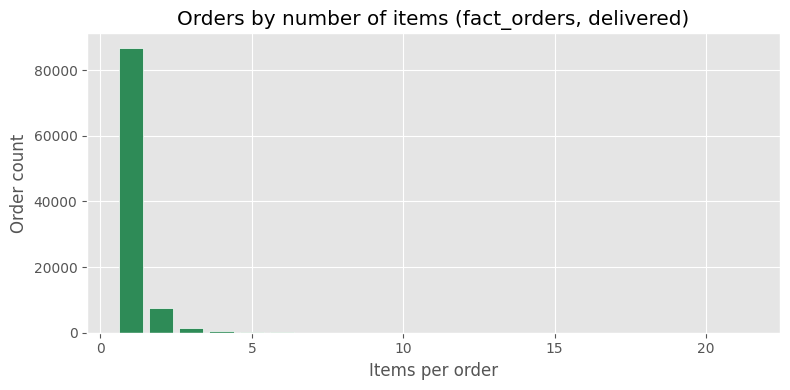

In [10]:
# Distribution of order size (items per order) from fact_orders
query_items_dist = f"""
SELECT total_items, COUNT(*) AS order_count
FROM {bq_table('fact_orders')}
WHERE order_status = 'delivered'
GROUP BY total_items
ORDER BY total_items
"""
df_items_dist = pandas_gbq.read_gbq(query_items_dist, project_id=BQ_PROJECT)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_items_dist["total_items"].astype(int), df_items_dist["order_count"], color='seagreen', edgecolor='white')
ax.set_title("Orders by number of items (fact_orders, delivered)")
ax.set_xlabel("Items per order")
ax.set_ylabel("Order count")
plt.tight_layout()
plt.show()

## 1. Monthly sales trends

In [11]:
query_monthly = f"""
SELECT
    DATE_TRUNC(order_date_key, MONTH) AS month,
    SUM(total_item_value) AS revenue,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(*) AS items_sold
FROM {bq_table('fact_order_items')}
GROUP BY 1
ORDER BY 1
"""
df_monthly = pandas_gbq.read_gbq(query_monthly, project_id=BQ_PROJECT)
df_monthly["month"] = pd.to_datetime(df_monthly["month"])
df_monthly.head(10)

Downloading: 100%|██████████|


,month,revenue,orders,items_sold
0,2016-09-01,354.750000000,3,6
1,2016-10-01,56808.840000000,308,363
2,2016-12-01,19.620000000,1,1
3,2017-01-01,137188.490000000,789,955
4,2017-02-01,286280.620000000,1733,1951
5,2017-03-01,432048.590000000,2641,3000
6,2017-04-01,412422.240000000,2391,2684
7,2017-05-01,586190.950000000,3660,4136
8,2017-06-01,502963.040000000,3217,3583
9,2017-07-01,584971.620000000,3969,4519


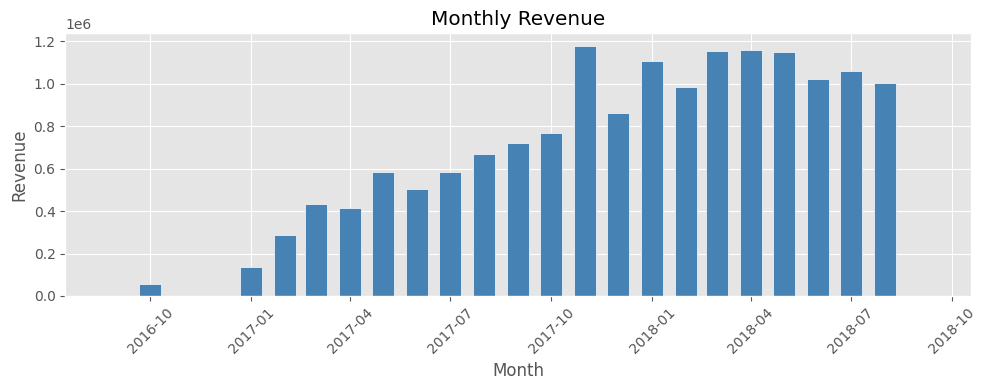

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_monthly["month"], df_monthly["revenue"], width=20, color='steelblue', edgecolor='white')
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Apples-to-apples: fact_orders vs fact_order_items (monthly)

Same population: **all orders** (no status filter). Revenue = sum of item value; order count = distinct orders. Both sources should match.

In [13]:
# Monthly from fact_orders (all orders) — same scope as Section 1
query_fo_monthly = f"""
SELECT
    DATE_TRUNC(order_date_key, MONTH) AS month,
    SUM(gross_order_value) AS revenue_fo,
    COUNT(*) AS orders_fo
FROM {bq_table('fact_orders')}
GROUP BY 1
ORDER BY 1
"""
df_fo_monthly = pandas_gbq.read_gbq(query_fo_monthly, project_id=BQ_PROJECT)
df_fo_monthly["month"] = pd.to_datetime(df_fo_monthly["month"])

# Merge with Section 1 (fact_order_items)
compare = df_monthly.merge(df_fo_monthly, on="month", how="outer").sort_values("month")
# Coerce to numeric in case BigQuery returned object dtype
compare["revenue"] = pd.to_numeric(compare["revenue"], errors="coerce")
compare["revenue_fo"] = pd.to_numeric(compare["revenue_fo"], errors="coerce")
compare["revenue_diff"] = (compare["revenue"] - compare["revenue_fo"]).round(2)
compare["orders_diff"] = (compare["orders"].astype(float) - compare["orders_fo"]).round(0)
print("Monthly comparison (fact_order_items vs fact_orders):")
display(compare)

# Totals
print("\nTotals:")
print(f"  fact_order_items: revenue={compare['revenue'].sum():,.0f}  orders={compare['orders'].sum():,.0f}")
print(f"  fact_orders:      revenue={compare['revenue_fo'].sum():,.0f}  orders={compare['orders_fo'].sum():,.0f}")
print(f"  Match: revenue diff={compare['revenue_diff'].sum():.2f}, orders diff={compare['orders_diff'].sum():.0f}")

Downloading: 100%|██████████|
Monthly comparison (fact_order_items vs fact_orders):


,month,revenue,orders,items_sold,revenue_fo,orders_fo,revenue_diff,orders_diff
0,2016-09-01,354.75,3,6,354.75,4,0.0,-1.0
1,2016-10-01,56808.84,308,363,56808.84,324,0.0,-16.0
2,2016-12-01,19.62,1,1,19.62,1,0.0,0.0
3,2017-01-01,137188.49,789,955,137188.49,800,0.0,-11.0
4,2017-02-01,286280.62,1733,1951,286280.62,1780,0.0,-47.0
5,2017-03-01,432048.59,2641,3000,432048.59,2682,0.0,-41.0
6,2017-04-01,412422.24,2391,2684,412422.24,2404,0.0,-13.0
7,2017-05-01,586190.95,3660,4136,586190.95,3700,0.0,-40.0
8,2017-06-01,502963.04,3217,3583,502963.04,3245,0.0,-28.0
9,2017-07-01,584971.62,3969,4519,584971.62,4026,0.0,-57.0



Totals:
  fact_order_items: revenue=15,843,553  orders=98,666
  fact_orders:      revenue=15,843,553  orders=99,441
  Match: revenue diff=0.00, orders diff=-771


## 2. Top-selling product categories

In [14]:
query_top = f"""
SELECT
    COALESCE(p.product_category_name, 'Unknown') AS category,
    SUM(f.total_item_value) AS revenue,
    COUNT(*) AS items_sold
FROM {bq_table('fact_order_items')} f
LEFT JOIN {bq_table('dim_product')} p ON p.product_key = f.product_key
GROUP BY 1
ORDER BY revenue DESC
LIMIT 15
"""
df_top = pandas_gbq.read_gbq(query_top, project_id=BQ_PROJECT)
df_top

Downloading: 100%|██████████|


,category,revenue,items_sold
0,beleza_saude,1441248.070000000,9670
1,relogios_presentes,1305541.610000000,5991
2,cama_mesa_banho,1241681.720000000,11115
3,esporte_lazer,1156656.480000000,8641
4,informatica_acessorios,1059272.400000000,7827
5,moveis_decoracao,902511.790000000,8334
6,utilidades_domesticas,778397.770000000,6964
7,cool_stuff,719329.950000000,3796
8,automotivo,685384.320000000,4235
9,ferramentas_jardim,584219.210000000,4347


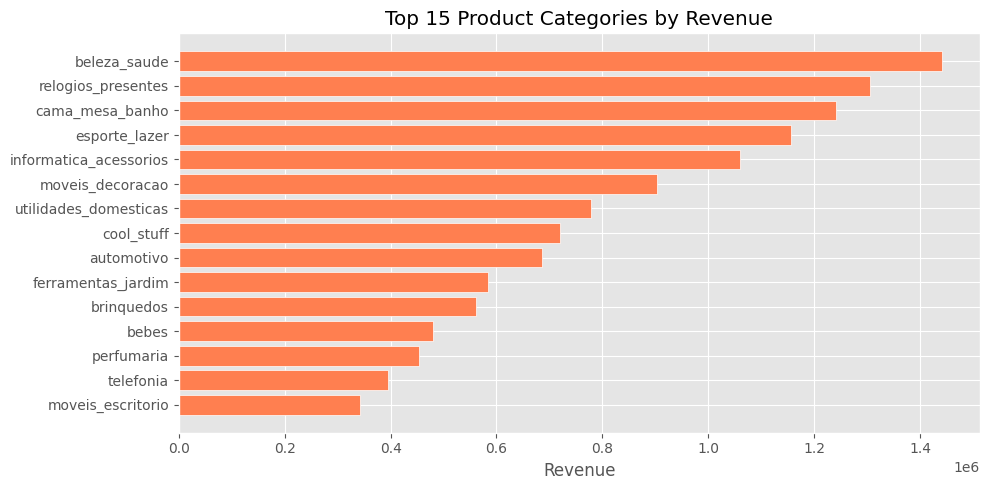

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top["category"].iloc[::-1], df_top["revenue"].iloc[::-1], color='coral', edgecolor='white')
ax.set_title("Top 15 Product Categories by Revenue")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

### Apples-to-apples (Section 2): Overall revenue & items

Section 2 uses **fact_order_items** (all orders). Here we compare **total** revenue and total items from that source vs **fact_orders** (same population: all orders). Category-level breakdown exists only in fact_order_items.

In [16]:
# Totals from Section 2 (fact_order_items) — coerce to native types (BigQuery may return Decimal)
rev_foi = float(df_top["revenue"].sum())
items_foi = int(df_top["items_sold"].sum())
# Totals from fact_orders (all orders)
query_fo_totals = f"""
SELECT
    SUM(gross_order_value) AS revenue_fo,
    SUM(total_items) AS items_fo,
    COUNT(*) AS orders_fo
FROM {bq_table('fact_orders')}
"""
tot = pandas_gbq.read_gbq(query_fo_totals, project_id=BQ_PROJECT)
rev_fo = float(tot["revenue_fo"].iloc[0])
items_fo = int(tot["items_fo"].iloc[0])
orders_fo = int(tot["orders_fo"].iloc[0])
print("Section 2 vs fact_orders (all orders):")
print(f"  fact_order_items: revenue={rev_foi:,.0f}  items={items_foi:,}")
print(f"  fact_orders:      revenue={rev_fo:,.0f}  items={items_fo:,}  orders={orders_fo:,}")
print(f"  Revenue diff: {rev_foi - rev_fo:,.2f}  Items diff: {items_foi - items_fo:,}")

Downloading: 100%|██████████|
Section 2 vs fact_orders (all orders):
  fact_order_items: revenue=12,106,489  items=87,757
  fact_orders:      revenue=15,843,553  items=112,650  orders=99,441
  Revenue diff: -3,737,064.69  Items diff: -24,893


## 3. Customer behavior & segmentation (tenure / CLV proxy)

In [17]:
query_seg = f"""
SELECT
    tenure_segment,
    COUNT(*) AS customers,
    SUM(total_revenue) AS total_revenue,
    ROUND(AVG(total_revenue), 2) AS avg_revenue_per_customer
FROM {bq_table('dim_customer')}
GROUP BY tenure_segment
ORDER BY total_revenue DESC
"""
df_seg = pandas_gbq.read_gbq(query_seg, project_id=BQ_PROJECT)
df_seg

Downloading: 100%|██████████|


,tenure_segment,customers,total_revenue,avg_revenue_per_customer
0,Established,59246,9438573.230000000,159.310000000
1,Loyal,29974,4790487.930000000,159.820000000
2,New,10221,1614492.080000000,157.960000000


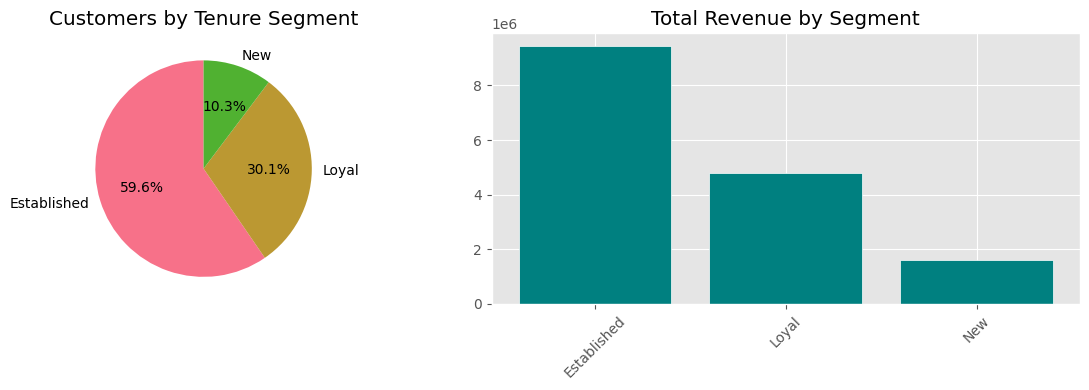

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(df_seg["customers"], labels=df_seg["tenure_segment"], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Customers by Tenure Segment")
axes[1].bar(df_seg["tenure_segment"], df_seg["total_revenue"], color='teal', edgecolor='white')
axes[1].set_title("Total Revenue by Segment")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Apples-to-apples (Section 3): Segment revenue & orders

Section 3 uses **dim_customer** (pre-aggregated total_revenue by customer). Here we get revenue and order count by **fact_orders** grouped by customer, join to **dim_customer** for tenure_segment, and compare segment totals to **df_seg**.

In [18]:
# Revenue and orders by customer from fact_orders, then by segment via dim_customer
query_seg_fo = f"""
SELECT
    c.tenure_segment,
    COUNT(DISTINCT fo.order_id) AS orders_fo,
    SUM(fo.gross_order_value) AS revenue_fo
FROM {bq_table('fact_orders')} fo
JOIN {bq_table('dim_customer')} c ON c.customer_id = fo.customer_id
GROUP BY c.tenure_segment
ORDER BY revenue_fo DESC
"""
df_seg_fo = pandas_gbq.read_gbq(query_seg_fo, project_id=BQ_PROJECT)
# Coerce numeric
df_seg["total_revenue"] = pd.to_numeric(df_seg["total_revenue"], errors="coerce")
df_seg_fo["revenue_fo"] = pd.to_numeric(df_seg_fo["revenue_fo"], errors="coerce")
compare_seg = df_seg.merge(
    df_seg_fo, on="tenure_segment", how="outer"
).sort_values("total_revenue", ascending=False)
compare_seg["revenue_diff"] = (compare_seg["total_revenue"] - compare_seg["revenue_fo"]).round(2)
print("Segment comparison (dim_customer / Section 3 vs fact_orders by segment):")
display(compare_seg)
print(f"\nTotals: Section 3 revenue={compare_seg['total_revenue'].sum():,.0f}  fact_orders revenue={compare_seg['revenue_fo'].sum():,.0f}  diff={compare_seg['revenue_diff'].sum():.2f}")

Downloading: 100%|██████████|
Segment comparison (dim_customer / Section 3 vs fact_orders by segment):


,tenure_segment,customers,total_revenue,avg_revenue_per_customer,orders_fo,revenue_fo,revenue_diff
0,Established,59246,9438573.23,159.310000000,59246,9438573.23,0.0
1,Loyal,29974,4790487.93,159.820000000,29974,4790487.93,0.0
2,New,10221,1614492.08,157.960000000,10221,1614492.08,0.0



Totals: Section 3 revenue=15,843,553  fact_orders revenue=15,843,553  diff=0.00


### Repeat customers (bought more than once)

Here we compute the **percentage of customers who placed more than one order** using `fact_orders` (customer-level order counts). This is a simple retention signal on top of the tenure segments.

In [21]:
# Share of repeat customers (customers with >1 order per *person*),
# using customer_unique_id from dim_customer + orders from fact_orders.
# In the Olist schema, customer_id is per-order, customer_unique_id is the person key.
query_repeat = f"""
WITH orders_per_person AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT fo.order_id) AS order_count
    FROM {bq_table('fact_orders')} fo
    JOIN {bq_table('dim_customer')} c
      ON c.customer_id = fo.customer_id
    WHERE c.tenure_segment != 'No orders'
    GROUP BY c.customer_unique_id
)
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) AS repeat_customers
FROM orders_per_person
"""

df_repeat = pandas_gbq.read_gbq(query_repeat, project_id=BQ_PROJECT)

total_customers = int(df_repeat["total_customers"].iloc[0])
repeat_customers = int(df_repeat["repeat_customers"].iloc[0])
repeat_pct = repeat_customers / total_customers * 100 if total_customers > 0 else 0

print(f"Total customers (unique people):      {total_customers:,}")
print(f"Repeat customers (people with >1 order): {repeat_customers:,}")
print(f"Repeat customer rate:                 {repeat_pct:,.1f}%")

Downloading: 100%|██████████|
Total customers (unique people):      96,096
Repeat customers (people with >1 order): 2,997
Repeat customer rate:                 3.1%


### Distribution of repeat behavior (1, 2, 3, 4+ orders)

We now bucket **unique people (`customer_unique_id`)** by how many orders they placed (1, 2, 3, 4+), and visualize the share of each group as a pie chart.

Downloading: 100%|██████████|
  order_bucket  customers  share_pct
0      1 order      93099  96.881244
1     2 orders       2745   2.856518
2     3 orders        203   0.211247
3    4+ orders         49   0.050991


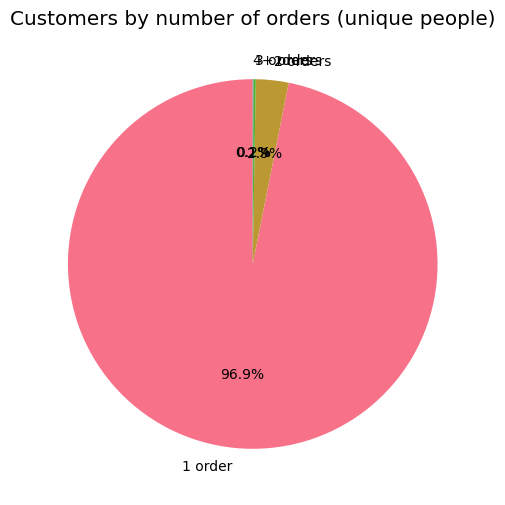

In [ ]:
# Distribution of orders per person (1, 2, 3, 4+), using customer_unique_id
query_repeat_dist = f"""
WITH orders_per_person AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT fo.order_id) AS order_count
    FROM {bq_table('fact_orders')} fo
    JOIN {bq_table('dim_customer')} c
      ON c.customer_id = fo.customer_id
    WHERE c.tenure_segment != 'No orders'
    GROUP BY c.customer_unique_id
),

bucketed AS (
    SELECT
        CASE
            WHEN order_count = 1 THEN '1 order'
            WHEN order_count = 2 THEN '2 orders'
            WHEN order_count = 3 THEN '3 orders'
            ELSE '4+ orders'
        END AS order_bucket,
        COUNT(*) AS customers
    FROM orders_per_person
    GROUP BY order_bucket
)
SELECT
    order_bucket,
    customers
FROM bucketed
ORDER BY
    CASE order_bucket
        WHEN '1 order' THEN 1
        WHEN '2 orders' THEN 2
        WHEN '3 orders' THEN 3
        ELSE 4
    END
"""

df_repeat_dist = pandas_gbq.read_gbq(query_repeat_dist, project_id=BQ_PROJECT)

df_repeat_dist["share_pct"] = df_repeat_dist["customers"] / df_repeat_dist["customers"].sum() * 100
print(df_repeat_dist)

# Pie chart of repeat behavior
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    df_repeat_dist["customers"],
    labels=df_repeat_dist["order_bucket"],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title("Customers by number of orders (unique people)")
plt.show()

## 4. Late delivery rate

In [ ]:
query_late = f"""
SELECT
    is_late_delivery,
    COUNT(*) AS items,
    SUM(total_item_value) AS revenue
FROM {bq_table('fact_order_items')}
WHERE delivery_date_key IS NOT NULL
GROUP BY is_late_delivery
"""
df_late = pandas_gbq.read_gbq(query_late, project_id=BQ_PROJECT)
total = df_late["items"].sum()
late_pct = df_late.loc[df_late["is_late_delivery"] == True, "items"].sum() / total * 100 if total else 0
print(f"Late delivery rate (by items): {late_pct:.1f}%")
df_late

Downloading: 100%|██████████|
Late delivery rate (by items): 6.6%


,is_late_delivery,items,revenue
0,False,102931,14268207.190000000
1,True,7265,1150936.220000000


**Note (Section 4 – late delivery):** Late delivery is defined at **item level** in **fact_order_items** (e.g. `delivery_date_key` / `is_late_delivery`). **fact_orders** has no delivery fields, so there is no fact_orders comparison for this metric.